#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import KMRF class
from kmrf import KMRF
from KMRF_training_config import *

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## 1. Configure KMRF Model

In [2]:
# Create DataFrame of asset names
asset_names_df = pd.DataFrame({
    'Investment Universe ETFs': get_assets_by_class('universe') + ['']*7,
    'US Equity ETFs': get_assets_by_class('us_equity'),
    'Commodities': get_assets_by_class('commodity') + ['']*5,
    'International Equity ETFs': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,Investment Universe ETFs,US Equity ETFs,Commodities,International Equity ETFs
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [ ]:
TRAINING_CONFIG = KMRF_Training_Config(
    asset_name= 'SPDR S&P 500 ETF',
    classification_type='original',
    use_data_type='master',
    end_date='20181231',
    feature_window_size=1,
    feature_asset_classes=[],
    cross_asset_specific=[],  # empty means all (only referring to universe assets)
    use_boruta_selection=True,
    use_consensus_selection=False
)
# You can also set cross_assets_to_include separately and pass it explicitly
# cross_assets_to_include = []

## 2. Initialize KMRF Model

In [4]:
# Initialize KMRF model with new features
model = KMRF(
    asset_class=TRAINING_CONFIG.get_asset_class(),
    asset_name=TRAINING_CONFIG.get_asset_name(),
    classification_type=TRAINING_CONFIG.get_classification_type(),
    end_date=TRAINING_CONFIG.get_date_ranges()['end_date'],
    use_data_type=TRAINING_CONFIG.get_use_data_type(),
    feature_window_size=TRAINING_CONFIG.get_feature_window_size(),  
    feature_asset_classes=TRAINING_CONFIG.get_cross_asset_features(),
    cross_asset_specific=TRAINING_CONFIG.get_cross_asset_specific(),
    xgb_params=TRAINING_CONFIG.get_xgb_params(),
    use_boruta_selection=TRAINING_CONFIG.get_use_boruta_selection(),
    use_consensus_selection=TRAINING_CONFIG.get_use_consensus_selection(),
)

print("\n" + "="*80)
print("KMRF MODEL INITIALIZED")
print("="*80)

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  End date: 20181231
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20181231
  Validation period: 2019-01-02 to 2021-12-31
  Test start: 2022-01-02
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=True, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}

KMRF MODEL INITIALIZED


## 3. Run Training Pipeline

In [5]:
model.pipeline(optimize=False)


KMRF PIPELINE FOR SPDR S&P 500 ETF
Asset Class: us_equity
Classification Type: original
Data Type: master
Feature Asset Classes: []
Cross-Asset Specifics: []
    ^ if empty, uses all assets in 'Feature Asset Classes'
Feature Window Size: 1
Use Boruta Selection: True
Use Consensus Selection: False

[Step 1/10] Loading Data...

Loading data from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 8242
  Columns: 95
  Date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00

[Step 2/10] Computing Features...

Extracting pre-computed features for SPDR S&P 500 ETF...
  Features shape: (8242, 95)

[Step 3/10] Loading KAMA+MSR Labels...

LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Loading from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_label_df.csv
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-30 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6023

  Or

## 4. Generate & Visualize Predictions


GENERATING VALIDATION PREDICTIONS

Generating predictions...
  Input shape: (757, 109)
  Using pre-selected features: 109
✓ Generated probability predictions: (757, 4)

Prediction probabilities shape: (757, 4)
Columns: ['P(LV_Bull)', 'P(LV_Bear)', 'P(HV_Bull)', 'P(HV_Bear)']

Sample predictions (first 10 days):
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2019-01-02    0.003785    0.820001    0.012923    0.163290
2019-01-03    0.003430    0.838108    0.010886    0.147575
2019-01-04    0.004672    0.698354    0.013925    0.283049
2019-01-07    0.003078    0.903962    0.006591    0.086370
2019-01-08    0.002680    0.944887    0.004978    0.047456
2019-01-09    0.002731    0.966537    0.003139    0.027593
2019-01-10    0.002020    0.978578    0.002966    0.016436
2019-01-11    0.001955    0.981870    0.002549    0.013626
2019-01-14    0.002081    0.984225    0.002762    0.010932
2019-01-15    0.001979    0.986111   

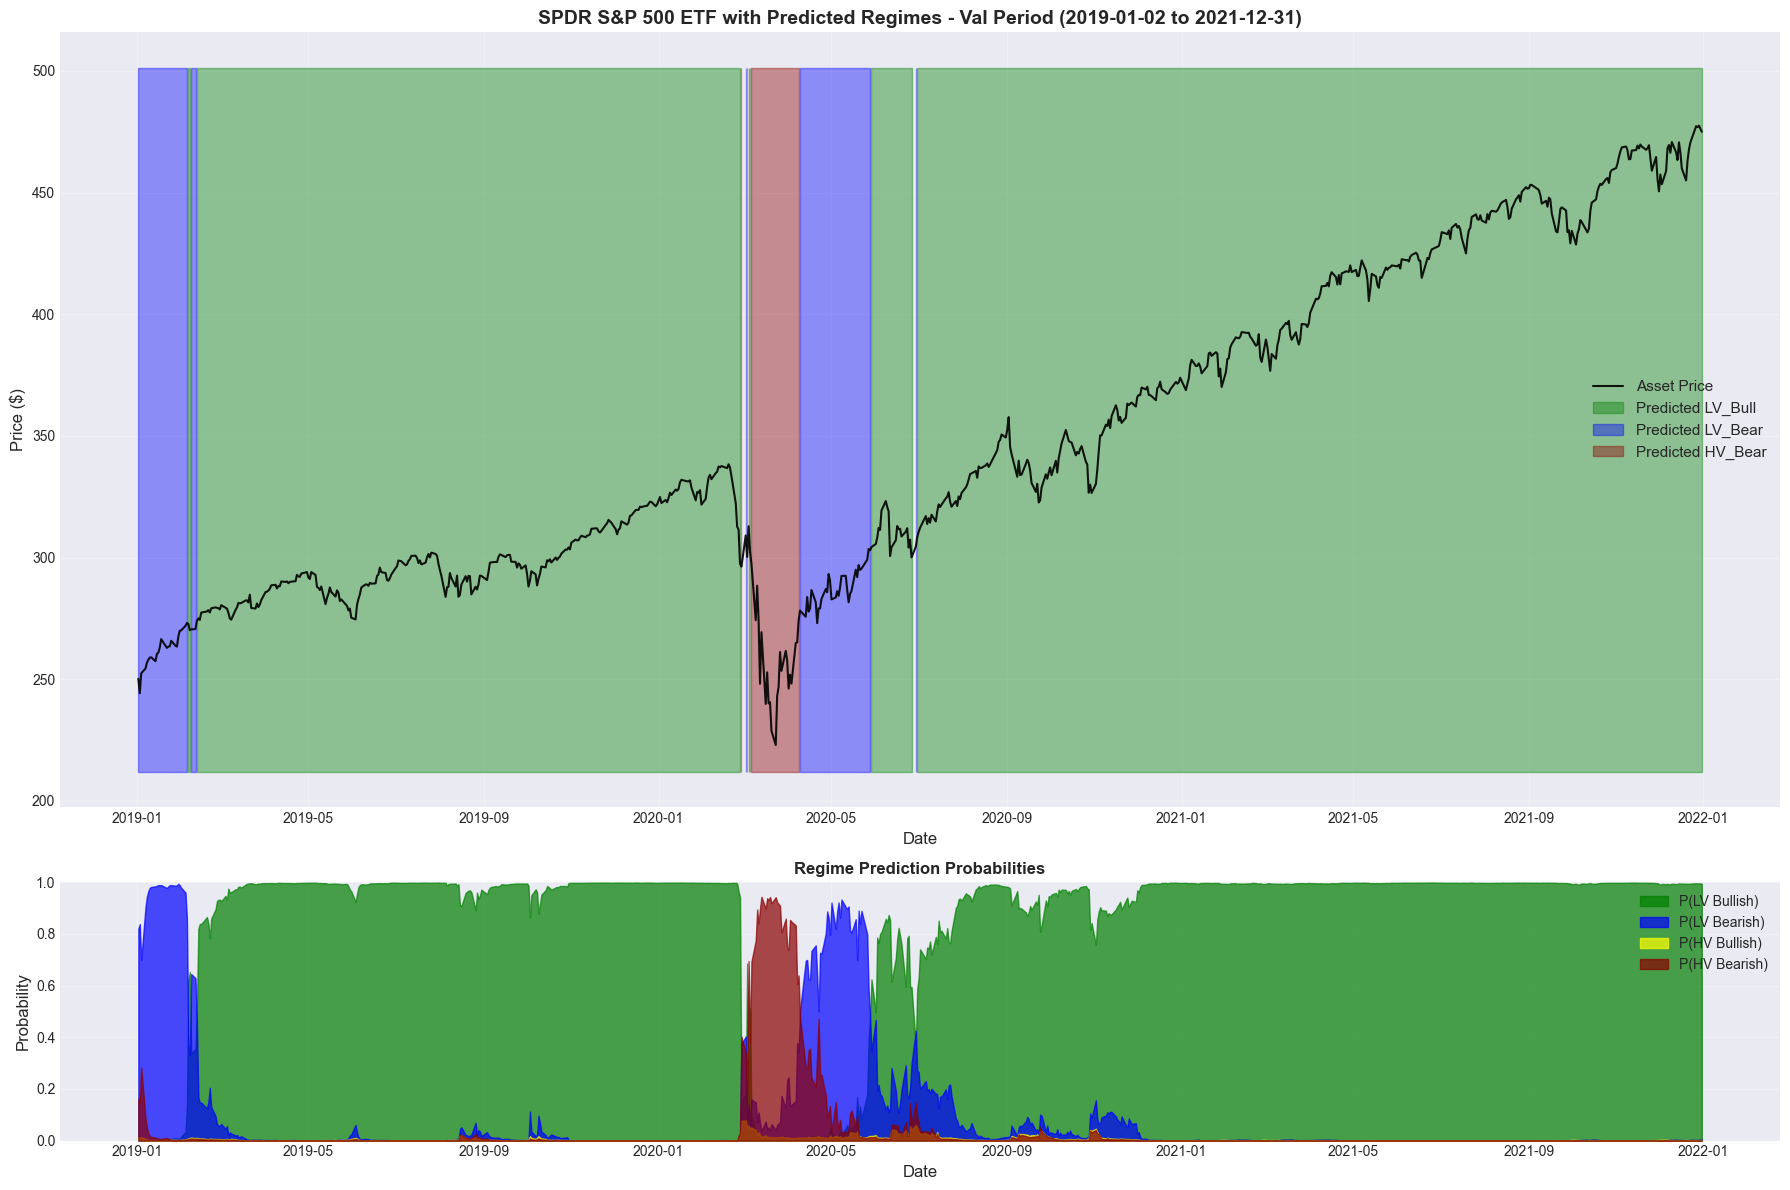

In [6]:
# Make predictions on validation set
print("\n" + "="*80)
print("GENERATING VALIDATION PREDICTIONS")
print("="*80)
test_or_val_set = 'val'  # Change to 'test' or 'val' as needed

y_val_pred_proba = model.predict(test_or_val=test_or_val_set)

print(f"\nPrediction probabilities shape: {y_val_pred_proba.shape}")
print(f"Columns: {list(y_val_pred_proba.columns)}")
print(f"\nSample predictions (first 10 days):")
print(y_val_pred_proba.head(10))

# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val=test_or_val_set)

## 5. Save Model

In [7]:
path = f'saved_models/KMRF_new/{model.classification_type}/{model.asset_class}/'
path += f'{model.asset_name.replace(" ", "_")}_KMRF_model.pkl'
model.save_model(path)


Saving model to: saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_model.pkl
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Features: 109
  Training samples: 5771
✓ Model saved successfully


PosixPath('saved_models/KMRF_new/original/us_equity/SPDR_S&P_500_ETF_KMRF_model.pkl')